In [1]:
import sys
sys.path.insert(0, "/home/winnieyangwn/rllm")
import importlib

import analysis.utils.eval_utils as eval_utils 

importlib.reload(eval_utils)
from analysis.utils.eval_utils import *

/storage/home/winnieyangwn/miniforge3/envs/aira-dojo/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
data_path = "/checkpoint/maui_sft/winnieyangwn/rllm/eval/multi_node_2_tasks_code/results/trajectories.jsonl"

In [3]:
import pandas as pd

df = pd.read_json(data_path, lines=True)


Found 119 rollouts matching valid criteria
Found 9 rollouts matching invalid criteria (excluding infra errors)
Found 0 rollouts with infrastructure errors


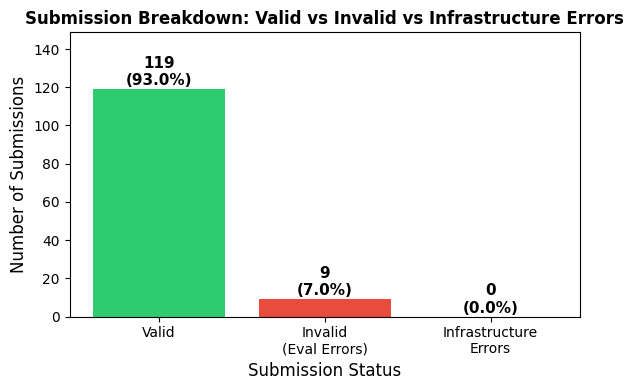

In [4]:
valid_df, invalid_df, infra_df = plot_submission_validity_breakdown(df)

In [ ]:
# Test process_df function
importlib.reload(eval_utils)
from analysis.utils.eval_utils import process_df

df_processed, df_task = process_df(df, Ks=[1, 4, 8, 16, 24, 32, 40, 48, 56, 64])

print("=== df_processed (rollout-level) ===")
print(f"Shape: {df_processed.shape}")


print("\n\n=== df_task (task-level) ===")
print(f"Shape: {df_task.shape}")
display(df_task)

In [ ]:
get_summary_stats(df)

{'total': 124,
 'valid_submissions': 119,
 'valid_rate': np.float64(95.96774193548387),
 'passed': 119,
 'pass_rate': np.float64(95.96774193548387),
 'avg_percentile': np.float64(0.4043372205772857),
 'min_percentile': np.float64(0.0),
 'max_percentile': np.float64(0.8148148148148141),
 'avg_score': np.float64(0.595834705882353)}

In [ ]:
df.shape

(124, 9)

Using pre-computed pass@k for 2 tasks
Tasks: ['mlsp-2013-birds', 'spooky-author-identification']


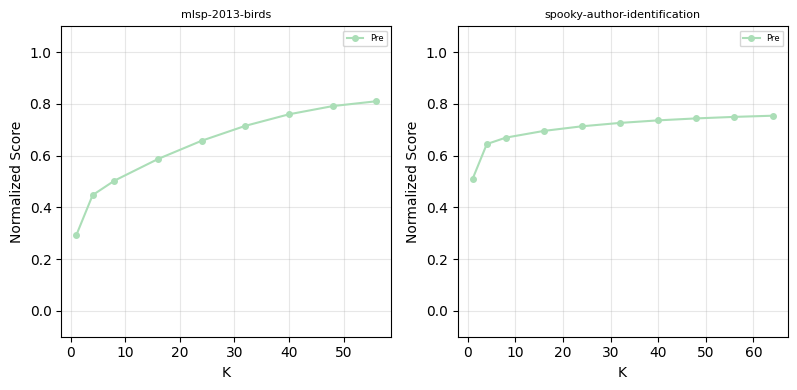

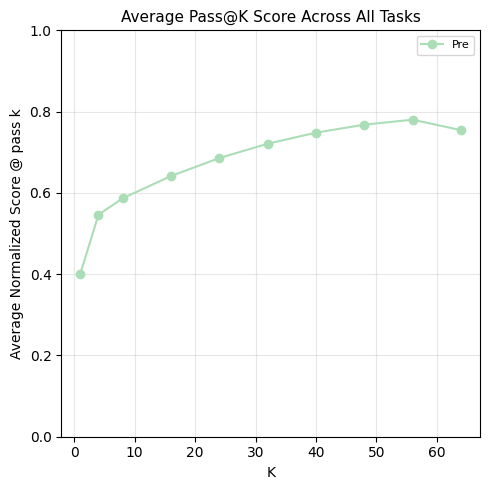

K	Pre
1	0.4008
4	0.5462
8	0.5866
16	0.6415
24	0.6857
32	0.7210
40	0.7482
48	0.7678
56	0.7801
64	0.7544


In [ ]:
# Test pass@k for percentile scores
results_df = plot_pass_at_k(df_task, metric="percentile")

In [ ]:
# Compare metrics across the full dataset
plot_metric_comparison([df_processed], labels=["All"], metric="percentile", agg="mean")


plot_metric_comparison([df_processed], labels=["All"], metric="medal", agg="mean")



Mean Percentile All: 0.4043 ± 0.2061


Mean Any Medal All: 0.0161 ± 0.1265
Mean Gold Medal All: 0.0000 ± 0.0000
Mean Silver Medal All: 0.0081 ± 0.0898
Mean Bronze Medal All: 0.0081 ± 0.0898


({'any_medal': {'values': [np.float64(0.016129032258064516)],
   'stds': [np.float64(0.12648281272371759)]},
  'gold_medal': {'values': [np.float64(0.0)], 'stds': [np.float64(0.0)]},
  'silver_medal': {'values': [np.float64(0.008064516129032258)],
   'stds': [np.float64(0.08980265101338747)]},
  'bronze_medal': {'values': [np.float64(0.008064516129032258)],
   'stds': [np.float64(0.08980265101338748)]}},
 None)